# Setup

In [1]:
%load_ext autoreload
%autoreload 2
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import healpy as hp
import rubin_sim.maf as maf
import rubin_scheduler.utils as rsUtils
import rubin_sim.data as data
import astropy.units as u
from astropy.coordinates import SkyCoord
from rubin_scheduler.utils import ra_dec2_hpid, hpid2_ra_dec
from rubin_scheduler.scheduler.utils import CurrentAreaMap, SkyAreaGeneratorGalplane, SkyAreaGenerator
from rubin_scheduler.scheduler.utils import EuclidOverlapFootprint
import astropy.io.fits as fits
from astropy.table import Table
# Add Skyfield directory to path to avoid conflicts
sys.path.insert(0, os.path.join(os.getcwd(), 'Skyfield', 'src'))
from utils import utils

### LSST Footprint

0 
1 LMC_SMC
2 bulgy
3 dusty_plane
4 euclid_overlap
5 lowdust
6 nes
7 scp
8 virgo
[0. 0. 0. ... 7. 7. 7.]


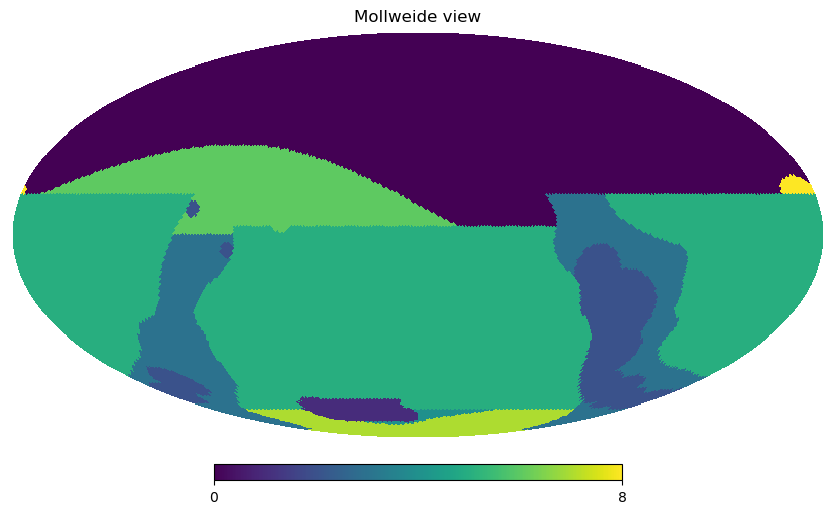

In [2]:
# generate the latest footprint
nside = 64
fpg = CurrentAreaMap(nside=nside)
maps_arr, labels = fpg.return_maps()

# Look at the labels
label_int = np.zeros(hp.nside2npix(nside))
for i,label in enumerate(np.unique(labels)):
    indx = np.where(labels == label)[0]
    label_int[indx] = i
    print(i, label)
print(label_int)
hp.mollview(label_int)

Check the Euclid Lowdust region

Area= 94.00088826365068  sq deg


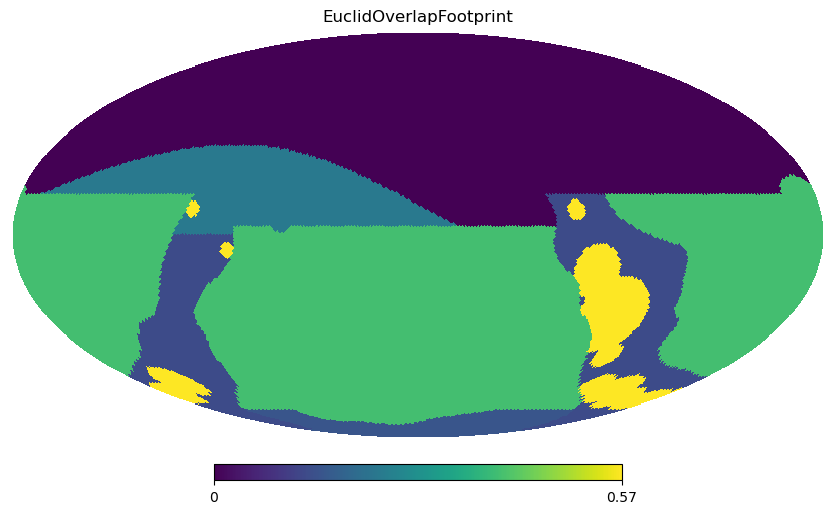

In [3]:
nside = 64
fpg = EuclidOverlapFootprint(nside=nside)
maps_arr, labels = fpg.return_maps()
wfd_pix = np.where((labels == "euclid_overlap"))[0]
hp_size = hp.nside2pixarea(nside, degrees=True)
print("Area=", np.size(wfd_pix)*hp_size, ' sq deg')
hp.mollview(maps_arr['g'], title='EuclidOverlapFootprint')

### Targets

We need to get coordinates for desired targets from the csv file.

In [4]:
targets_dir = '/data/a.saricaoglu/repo/RubinsForge'
targets_file = os.path.join(targets_dir, 'targets.csv')

targets = utils.read_targets_file(targets_file, verbose=True)


CSV file structure:
Shape: (17836, 19)
Columns: ['ra', 'dec', 'name', 'alt_name', 'flag', 'score', 'image_sep', 'info', 'n_img', 'image_conf', 'lens_type', 'source_type', 'contaminant_type', 'lens_spec_z', 'lens_phot_z', 'source_spec_z', 'source_phot_z', 'z_lens', 'z_source']

First few rows:
        ra       dec                          name  \
0  0.02540  21.64150                    J0000+2138   
1  0.03083 -33.68306              J000007.4-334059   
2  0.03524   2.44944             HSCJ000008+022658   
3  0.03690  21.28410                    J0000+2117   
4  0.05013 -31.16204  KiDSDR4J000012.031-310943.35   

                         alt_name       flag  score  image_sep info  n_img  \
0                             NaN  CANDIDATE   1.88        NaN  NaN    NaN   
1                             NaN  CANDIDATE   1.00        NaN  NaN    NaN   
2  J00h00m08.4576s +02d26m57.984s  CANDIDATE   1.75        NaN  NaN    NaN   
3                             NaN  CANDIDATE   1.88        NaN  NaN  

Check target object structure

In [5]:

print(f"Target IDs: {list(targets.keys())[:5]}...")  # Show first 5 IDs
print(f'Number of candidates: {len([t for t in targets.values() if t["flag"]=="CANDIDATE"])}')
print(f'Number of confirmed: {len([t for t in targets.values() if t["flag"]=="CONFIRMED"])}')
# Show structure of first target
first_target_id = list(targets.keys())[0]
print(f"\nStructure of {first_target_id}:")
for key, value in targets[first_target_id].items():
    if key != 'coord':  # Skip coord object for cleaner display
        print(f"  {key}: {value}")

Target IDs: ['target_0000', 'target_0001', 'target_0002', 'target_0003', 'target_0004']...
Number of candidates: 16851
Number of confirmed: 985

Structure of target_0000:
  ra: 0.0254
  dec: 21.6415
  name: J0000+2138
  flag: CANDIDATE
  n_img: nan
  image_conf: []
  lens_type: ['GALAXY']
  source_type: []
  mag: None
  Dmag: None
  value: None
  dvalue_min: None
  dvalue_max: None


# LSST Footprint Target Selection

Now, check how many targets are inside the footprint

In [22]:

# Create targets dictionary with all requested fields
coordinates = SkyCoord([targets[tid]['coord'] for tid in targets.keys()])
targets_in_footprint = {}
names = []
coordinates_in_footprint = []
for coord, target in zip(coordinates, targets.values()):
    hpid = ra_dec2_hpid(nside, coord.ra.degree, coord.dec.degree)
    healpixval = 0
    for filtername in 'ugrizy':
        healpixval += maps_arr[filtername][hpid]
    if healpixval > 0:
        # targets_in_footprint.append(coord)
        index = len(targets_in_footprint) # Simple index for naming
        # Create target ID (you can modify this naming scheme)
        target_id = f"target_{index:04d}"
        # Build the target dictionary with all requested fields
        targets_in_footprint[target_id] = target

        names.append(target['name'])
        coordinates_in_footprint.append(coord)

coordinates_in_footprint = SkyCoord(coordinates_in_footprint)

In [7]:
print(f"\nCreated targets dictionary with {len(targets_in_footprint)} targets")
print(f'Number of candidates: {len([t for t in targets_in_footprint.values() if t["flag"]=="CANDIDATE"])}')
print(f'Number of confirmed: {len([t for t in targets_in_footprint.values() if t["flag"]=="CONFIRMED"])}')
print(f"Number of total lenses: {len(targets)}")


Created targets dictionary with 13740 targets
Number of candidates: 13151
Number of confirmed: 589
Number of total lenses: 17836


Further specilalize the target list to the Euclid Lowdust region

In [8]:
EuLd_pix = np.where((labels == 'lowdust') | (labels == "euclid_overlap"))[0]
coordinates_in_EuLd = []
ids = []
euld_names = []
euld_flags = []
for target in targets_in_footprint.keys():
    coord = targets_in_footprint[target]['coord']
    hpid = ra_dec2_hpid(nside, coord.ra.degree, coord.dec.degree)
    healpixval = 0
    for filtername in 'ugrizy':
        healpixval += maps_arr[filtername][hpid]
    if (healpixval > 0) & (hpid in EuLd_pix):
        ids.append(target)
        coordinates_in_EuLd.append(coord)
        euld_names.append(targets_in_footprint[target]['name'])
        euld_flags.append(targets_in_footprint[target]['flag'])
coordinates_in_EuLd = SkyCoord(coordinates_in_EuLd)

In [9]:
print(f'Number of candidates: {len([t for t in euld_flags if t=="CANDIDATE"])}')
print(f'Number of confirmed: {len([t for t in euld_flags if t=="CONFIRMED"])}')
print(f"Number of lenses in Euclid/Lowdust region: {len(coordinates_in_EuLd)}")
print(f"Number of lenses in footprint {len(coordinates)}")

Number of candidates: 12493
Number of confirmed: 526
Number of lenses in Euclid/Lowdust region: 13019
Number of lenses in footprint 17836


Save choosen targets to a file for later use.

In [23]:
repo_path = os.path.join(os.getcwd())
fits_filename = os.path.join(repo_path, 'in_LSST_footprint_coordinates.fits')

# Simple ASCII-only cleaning function
def simple_ascii_clean(text):
    """Keep only ASCII characters"""
    if text is None:
        return 'None'
    return ''.join(char for char in str(text) if ord(char) < 128)

# Clean the names
clean_names = [simple_ascii_clean(name) for name in names]
clean_euld_names = [simple_ascii_clean(name) for name in euld_names]

hdu = fits.PrimaryHDU()
hdul = fits.HDUList([hdu])
hdul.writeto(fits_filename, overwrite=True)
hdu = fits.open(fits_filename, mode='update')

table1 = fits.BinTableHDU(Table(data=[list(targets_in_footprint.keys()), clean_names, coordinates_in_footprint.ra.degree, coordinates_in_footprint.dec.degree], names=['Target_no', 'SLEDName', 'RA', 'DEC'], units=['', '', 'deg', 'deg']))
table2 = fits.BinTableHDU(Table(data=[ids, clean_euld_names, coordinates_in_EuLd.ra.degree, coordinates_in_EuLd.dec.degree], names=['Target_no', 'SLEDName', 'RA', 'DEC'], units=['', '', 'deg', 'deg']))
table1.header['EXTNAME'] = 'In_LSST_Footprint'
table2.header['EXTNAME'] = 'In_Euclid_Lowdust_Region'
table1.header['NOBJ'] = len(coordinates_in_footprint)
table2.header['NOBJ'] = len(coordinates_in_EuLd)
table1.header['COMMENT'] = "Lenses inside LSST footprint in any band"
table2.header['COMMENT'] = "Lenses inside Euclid overlap and lowdust region"

hdu.append(table1)
hdu.append(table2)
hdu.flush()